**Importing Libraries**

First we need to import all the necessary libraries.

(From Activity 1.1: Importing the libraries, Epic 1)

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import warnings
import pickle
from scipy import stats
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')

**Loading the Dataset from the given csv file**

We first have to upload the csv file onto Google Colab, and use pandas library to read it into a dataframe 'df'

(From EPIC 1, Activity 1.2: Read the Dataset)

In [54]:
#Loading the dataset from the csv file

df = pd.read_csv('/content/insurance_claims.csv')

df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [55]:
#Basic information about dataset

df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

**Checking for Null values**

Most important thing in training a ML model is to deal with any missing values that might be there in the dataset.

These values can be trated in 2 ways:
1. If the number of NaN values is way too large, we can drop that column
2. If that count is still less, we can fill the 'NaN' values with a better label "Unknown" (For Example, not a needed practice)

(From Activity 2: Data Preparation, EPIC 2)

In [56]:
#Checking for null values

# Check missing values per column
missing_values = df.isna().sum()

print(missing_values)

# Total missing values
print("Total missing values:", missing_values.sum())

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

In [57]:
#Deal with the NaN vaue columns

#Two columns with NaN values were detected: _c39 and authorities_contacted
#_c39 column can be dropped, while the other column can be imputed

#Drop _c39 column
df.drop('_c39', axis=1, inplace=True)

#Imputing authorities_contacted column
df['authorities_contacted'].fillna('Unknown', inplace=True)

#Final Check
print(df.isna().sum())

months_as_customer             0
age                            0
policy_number                  0
policy_bind_date               0
policy_state                   0
policy_csl                     0
policy_deductable              0
policy_annual_premium          0
umbrella_limit                 0
insured_zip                    0
insured_sex                    0
insured_education_level        0
insured_occupation             0
insured_hobbies                0
insured_relationship           0
capital-gains                  0
capital-loss                   0
incident_date                  0
incident_type                  0
collision_type                 0
incident_severity              0
authorities_contacted          0
incident_state                 0
incident_city                  0
incident_location              0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
property_damage                0
bodily_injuries                0
witnesses                      0
police_rep

**Detection of Outliers**

Having dealt with the presence of null values, we can now move on further with dealing with Outliers

(From Activity 2.2)

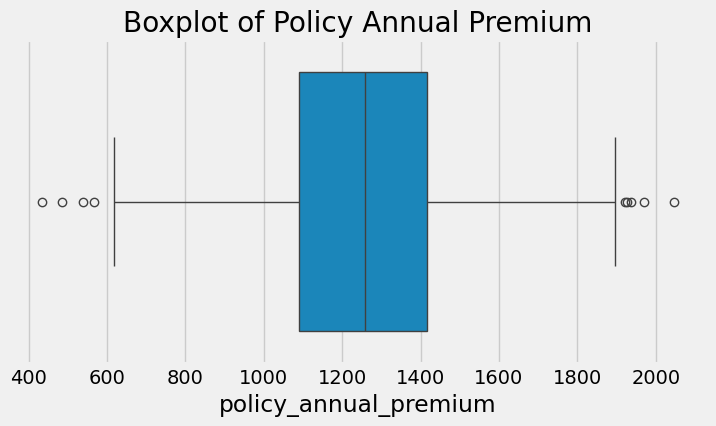

In [58]:
# Using Boxplot to detect Outliers

plt.figure(figsize=(8,4))
sns.boxplot(x=df['policy_annual_premium'])
plt.title("Boxplot of Policy Annual Premium")
plt.show()

In [59]:
#Computing the Quartiles, IQR and Lower and Upper Bounds

Q1 = df['policy_annual_premium'].quantile(0.25)
Q3 = df['policy_annual_premium'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 600.4762499999999
Upper Bound: 1904.8262500000003


In [60]:
#Finding Outliers

outliers = df[(df['policy_annual_premium'] < lower_bound) |
              (df['policy_annual_premium'] > upper_bound)]

print("Number of outliers:", len(outliers))

Number of outliers: 9


In [61]:
#Apply log transformations to such outliers

df['policy_annual_premium_log'] = np.log(df['policy_annual_premium'])

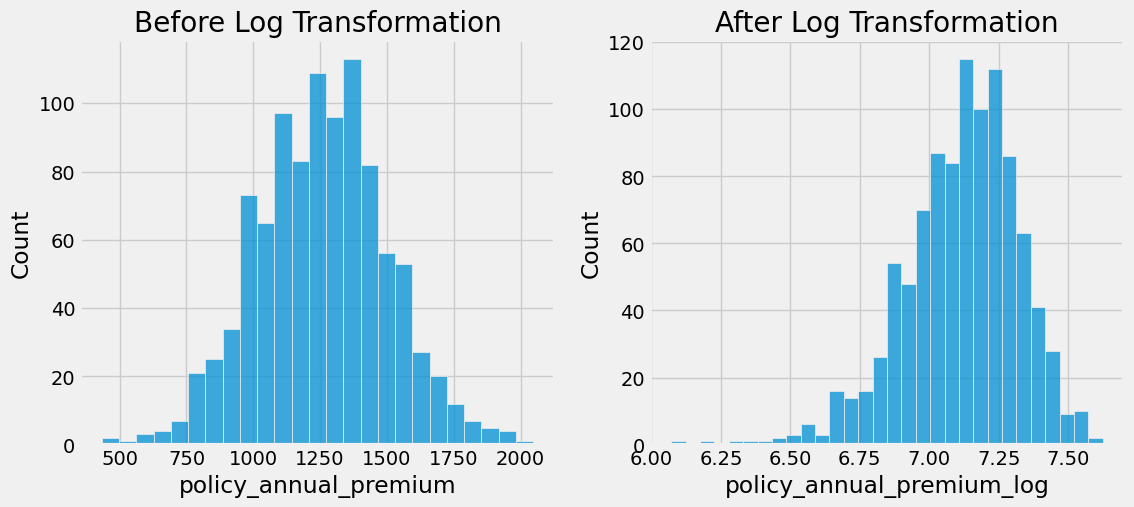

In [62]:
#Visual Outputs before and after the transformations

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['policy_annual_premium'])
plt.title("Before Log Transformation")

plt.subplot(1,2,2)
sns.histplot(df['policy_annual_premium_log'])
plt.title("After Log Transformation")

plt.show()

**Exploratory Data Analysis (EDA)**

To begin with, we first need to 'explore' our given dataset.

Now, we will perform "Univariate Analysis" of our data.

We will provide a total of 3 visualisations:

1. Countplot of reported frauds
2. Pie Chart of the severity of incidents reported
3. Age distribution using histogram

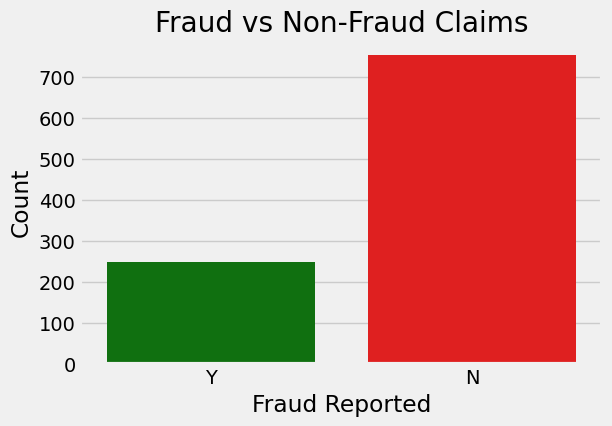

In [63]:
#Countplot of Fraud Cases

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='fraud_reported',
    palette=['green','red']
)

plt.title("Fraud vs Non-Fraud Claims")
plt.xlabel("Fraud Reported")
plt.ylabel("Count")

plt.show()

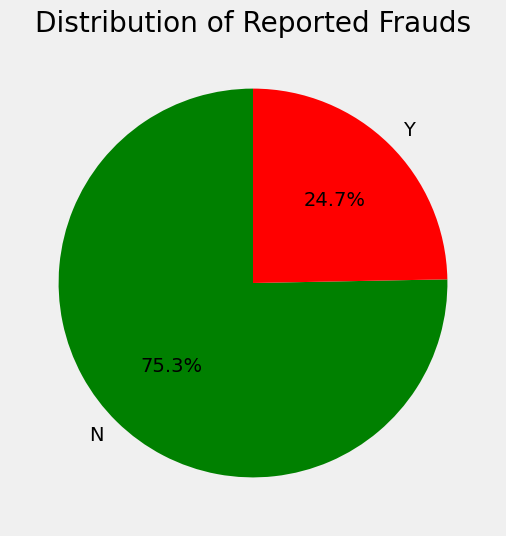

In [64]:
fraud_counts = df['fraud_reported'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(fraud_counts, labels=fraud_counts.index, autopct='%1.1f%%', startangle=90, colors=['green', 'red'])
plt.title('Distribution of Reported Frauds')
plt.show()

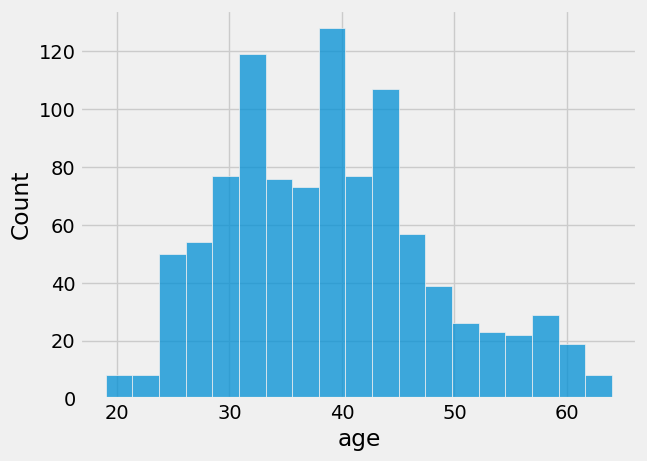

In [65]:
#Age Distribution

sns.histplot(df['age'])
plt.show()

Now, we shall perform "Multivariate Analysis" using co-relation heat maps

(From Story 2.3)

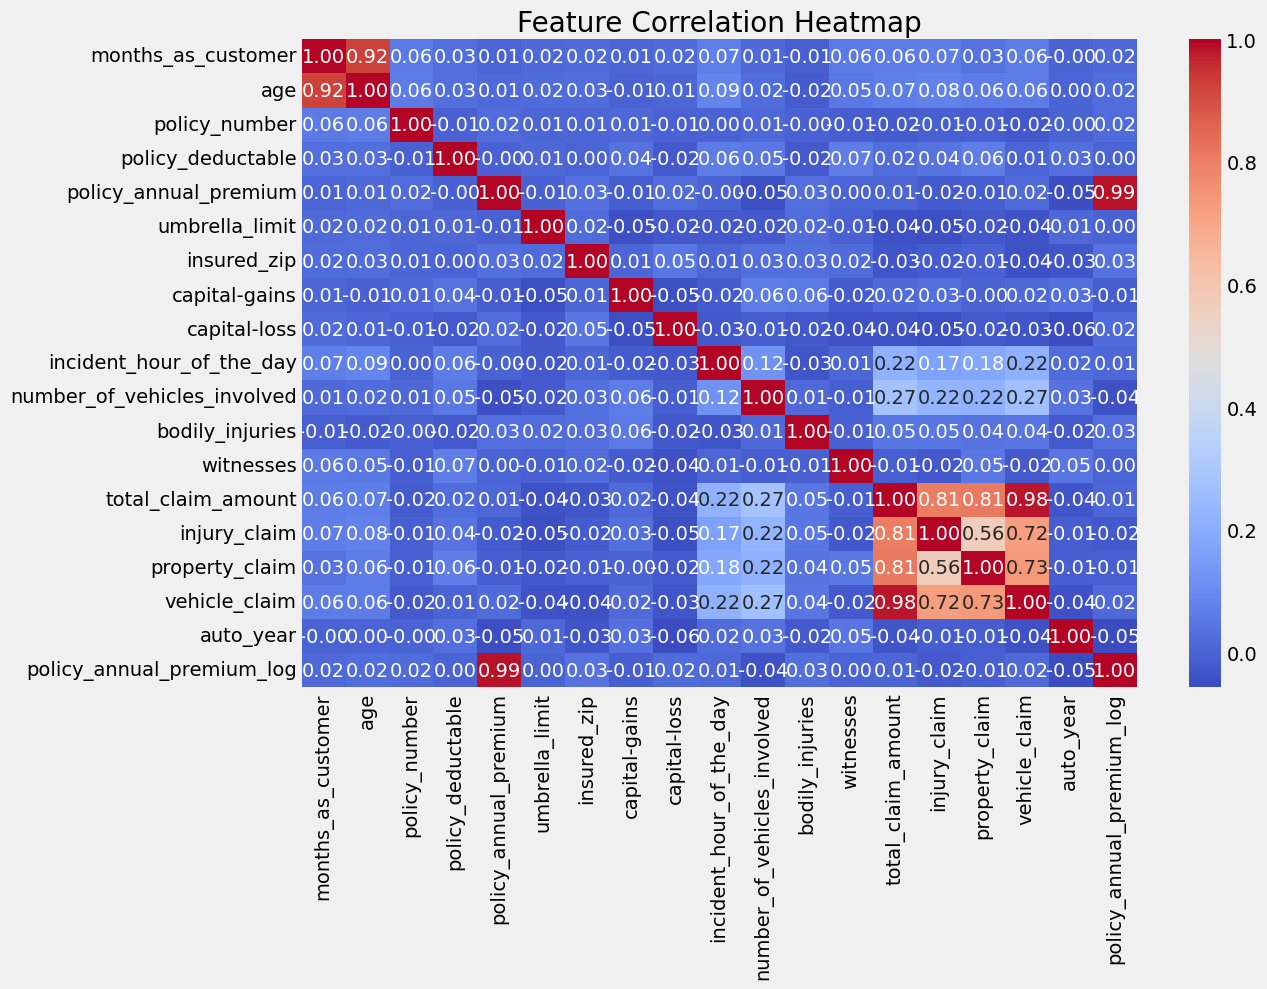

In [66]:
#Co-relation heatmap

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [67]:
#Dropping Highly Co-related columns

df = df.drop(columns=['injury_claim','property_claim','vehicle_claim'])
df = df.drop(columns=['months_as_customer'])

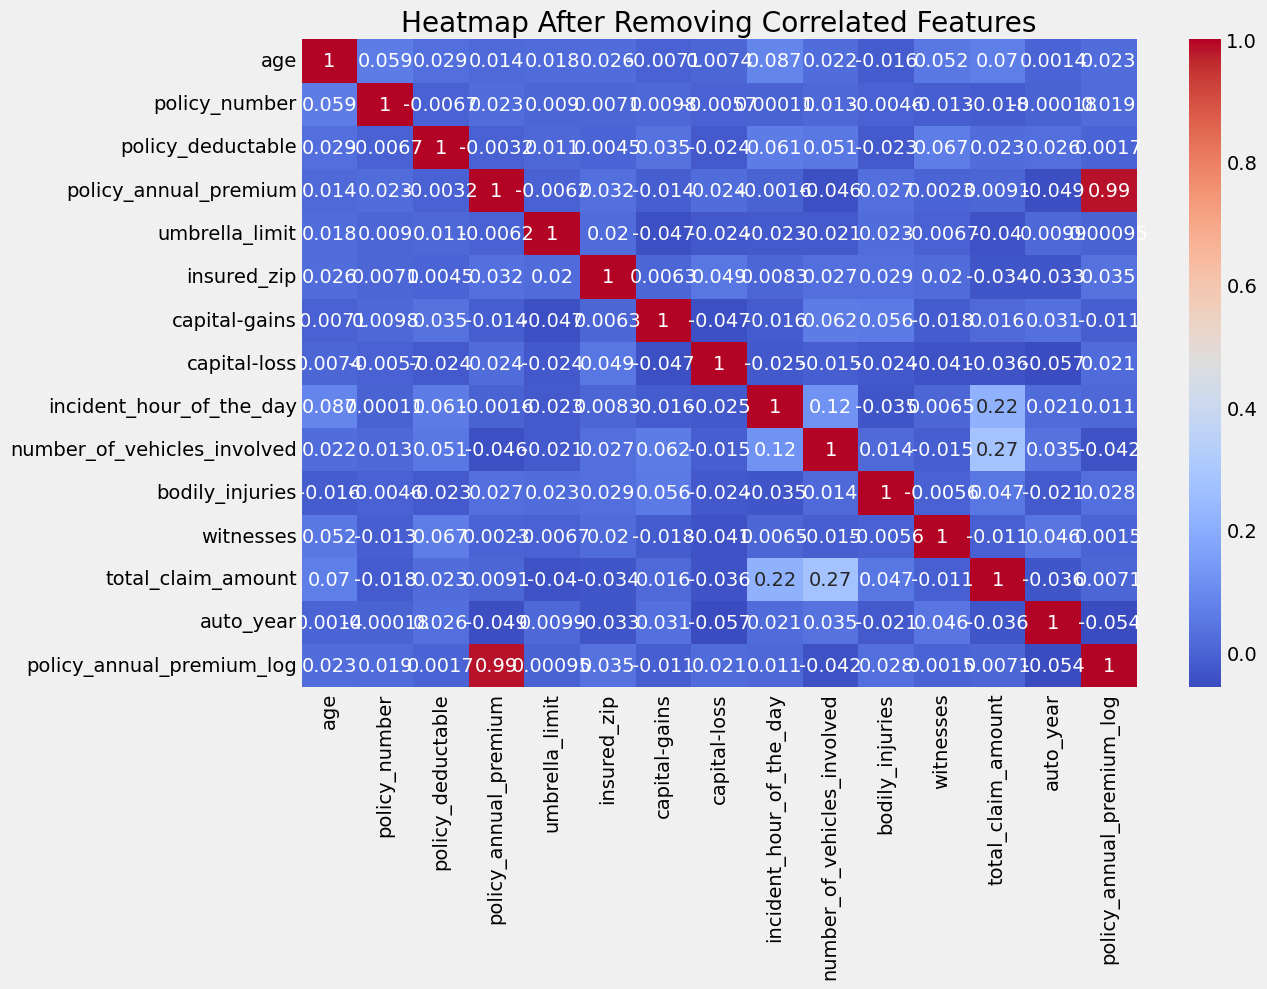

In [68]:
#Re-plotting the heat map

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True)
plt.title("Heatmap After Removing Correlated Features")
plt.show()

**Encoding the Categorical Columns**

We now need to prepare our dataset for Machine Learning. Most important thing to do now is to encode all the categorical columns into numerical values.

In [69]:
#Finding out categorical columns

categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'incident_date', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'incident_state', 'incident_city', 'incident_location',
       'property_damage', 'police_report_available', 'auto_make', 'auto_model',
       'fraud_reported'],
      dtype='object')


In [70]:
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])
df['incident_date'] = pd.to_datetime(df['incident_date'])

df['claim_delay'] = (df['incident_date'] - df['policy_bind_date']).dt.days

df = df.drop(columns=['policy_bind_date','incident_date'])

In [71]:
le = LabelEncoder()

categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [72]:
X = df.drop('fraud_reported', axis=1)
y = df['fraud_reported']

In [73]:
#Splitting the data into testing and training sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (800, 34)
Testing set: (200, 34)


**Scaling the data**

Next step is to scale our data, using the Standard Scaler from scikit learn.

In [74]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
print("Mean after scaling:", np.mean(X_train_scaled))
print("Std after scaling:", np.std(X_train_scaled))

Mean after scaling: 3.491977948629831e-16
Std after scaling: 1.0


**Model Training**

First, we will train the Decision Tree Model (Decision Tree Classifier)

(From Epic 4, Activity 4.1)

In [76]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [77]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, dt_model.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, y_pred_dt))

Train Accuracy: 1.0
Test Accuracy: 0.755


In [78]:
#Confusion Matrix

print(confusion_matrix(y_test, y_pred_dt))

[[118  27]
 [ 22  33]]


In [79]:
#Classification Report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.84      0.81      0.83       145
           1       0.55      0.60      0.57        55

    accuracy                           0.76       200
   macro avg       0.70      0.71      0.70       200
weighted avg       0.76      0.76      0.76       200



**Model Training (Continued)**

Now, we will train the Random Forest Model.

In [80]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, rf_model.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, y_pred_rf))

Train Accuracy: 1.0
Test Accuracy: 0.73


In [81]:
#Confusion Matrix

print(confusion_matrix(y_test, y_pred_rf))

[[134  11]
 [ 43  12]]


In [82]:
#Classification Matrix

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.76      0.92      0.83       145
           1       0.52      0.22      0.31        55

    accuracy                           0.73       200
   macro avg       0.64      0.57      0.57       200
weighted avg       0.69      0.73      0.69       200



**Model Training (Continued)**

Now we will train the KNeighbourClassifier Model (KNN)

In [83]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print("Test Accuracy:", accuracy_score(y_test, y_pred_knn))

[[133  12]
 [ 49   6]]
              precision    recall  f1-score   support

           0       0.73      0.92      0.81       145
           1       0.33      0.11      0.16        55

    accuracy                           0.69       200
   macro avg       0.53      0.51      0.49       200
weighted avg       0.62      0.69      0.63       200

Test Accuracy: 0.695


**Model Training (Continued)**

Now we will train next model: The Logistic Regression Model

In [84]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_log))
print("Test Accuracy:", accuracy_score(y_test, y_pred_log))

[[128  17]
 [ 41  14]]
Test Accuracy: 0.71


**Model Training (Continued)**

Next model to be trained: Naïve Bayes Model

In [85]:
nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

print("Train Accuracy:", accuracy_score(y_train, nb_model.predict(X_train_scaled)))
print("Test Accuracy:", accuracy_score(y_test, y_pred_nb))

Train Accuracy: 0.7925
Test Accuracy: 0.7


In [86]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Confusion Matrix:
[[117  28]
 [ 32  23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       145
           1       0.45      0.42      0.43        55

    accuracy                           0.70       200
   macro avg       0.62      0.61      0.61       200
weighted avg       0.69      0.70      0.70       200



**Model Training (Continued)**

Next model to train is: SVM Model

In [87]:
svm_model = SVC(kernel='rbf')

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print("Test Accuracy:", accuracy_score(y_test, y_pred_svm))

[[141   4]
 [ 55   0]]
              precision    recall  f1-score   support

           0       0.72      0.97      0.83       145
           1       0.00      0.00      0.00        55

    accuracy                           0.70       200
   macro avg       0.36      0.49      0.41       200
weighted avg       0.52      0.70      0.60       200

Test Accuracy: 0.705


**Model Testing**

Now, we will test all the above trained models using the predict() function!

In [88]:
#Decision Tree Model

sample_claim = [X.iloc[10].values]

dt_prediction = dt_model.predict(sample_claim)

print("Decision Tree Prediction:", dt_prediction)

prediction = rf_model.predict(sample_claim)

if prediction[0] == 1:
    print("Fraudulent Insurance Claim")
else:
    print("Legitimate Insurance Claim")

Decision Tree Prediction: [0]
Legitimate Insurance Claim


In [89]:
#Random Forest Model

sample_claim = [X.iloc[10].values]

rf_prediction = rf_model.predict(sample_claim)

print("\nRandom Forest Prediction:", rf_prediction)

if rf_prediction[0] == 1:
    print("Random Forest: Fraudulent Insurance Claim")
else:
    print("Random Forest: Legitimate Insurance Claim")



Random Forest Prediction: [0]
Random Forest: Legitimate Insurance Claim


In [90]:
#KNN Model

sample_claim_scaled = scaler.transform(sample_claim)

knn_prediction = knn_model.predict(sample_claim_scaled)

print("\nKNN Prediction:", knn_prediction)

if knn_prediction[0] == 1:
    print("KNN: Fraudulent Insurance Claim")
else:
    print("KNN: Legitimate Insurance Claim")


KNN Prediction: [0]
KNN: Legitimate Insurance Claim


In [91]:
#Logistic Regression Model

sample_claim_scaled = scaler.transform(sample_claim)

log_prediction = log_model.predict(sample_claim_scaled)

print("\nLogistic Regression Prediction:", log_prediction)

if log_prediction[0] == 1:
    print("Logistic Regression: Fraudulent Insurance Claim")
else:
    print("Logistic Regression: Legitimate Insurance Claim")


Logistic Regression Prediction: [0]
Logistic Regression: Legitimate Insurance Claim


In [92]:
#Naive Bayes Model

sample_claim_scaled = scaler.transform(sample_claim)

nb_prediction = nb_model.predict(sample_claim_scaled)

print("\nNaive Bayes Prediction:", nb_prediction)

if nb_prediction[0] == 1:
    print("Naive Bayes: Fraudulent Insurance Claim")
else:
    print("Naive Bayes: Legitimate Insurance Claim")


Naive Bayes Prediction: [0]
Naive Bayes: Legitimate Insurance Claim


In [93]:
#SVM Model

sample_claim_scaled = scaler.transform(sample_claim)

svm_prediction = svm_model.predict(sample_claim_scaled)

print("\nSVM Prediction:", svm_prediction)

if svm_prediction[0] == 1:
    print("SVM: Fraudulent Insurance Claim")
else:
    print("SVM: Legitimate Insurance Claim")


SVM Prediction: [0]
SVM: Legitimate Insurance Claim


**Comparing the Models**



In [94]:
#Defining the compareModel() function

def compareModel(model, X_train, X_test, y_train, y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Predict test data
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

In [95]:
#Comaprision Table of all models

model_results = {
    "Decision Tree": compareModel(dt_model, X_train, X_test, y_train, y_test),
    "Random Forest": compareModel(rf_model, X_train, X_test, y_train, y_test),
    "KNN": compareModel(knn_model, X_train_scaled, X_test_scaled, y_train, y_test),
    "Logistic Regression": compareModel(log_model, X_train_scaled, X_test_scaled, y_train, y_test),
    "Naive Bayes": compareModel(nb_model, X_train_scaled, X_test_scaled, y_train, y_test),
    "SVM": compareModel(svm_model, X_train_scaled, X_test_scaled, y_train, y_test)
}

print(model_results)

{'Decision Tree': 0.755, 'Random Forest': 0.73, 'KNN': 0.695, 'Logistic Regression': 0.71, 'Naive Bayes': 0.7, 'SVM': 0.705}


**Cross-Validation**

In [96]:
scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross Validation Scores: [0.755 0.78  0.75  0.775 0.79 ]
Mean Accuracy: 0.77


In [97]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': 20, 'n_estimators': 100}
Best Score: 0.7925000000000001


**Saving the Model**

Out of the above trained models, we will use the Random Forest Model. But for using it, we first need to save it.

In [98]:
best_rf_model = grid.best_estimator_
print(best_rf_model)

RandomForestClassifier(max_depth=20)


In [99]:
pickle.dump(best_rf_model, open("model.pkl", "wb"))